<a href="https://colab.research.google.com/github/rrand-04/AI-Project1-Optimization-Strategies-for-Local-Package-Delivery-Operations/blob/main/spectrogram_cnn_deepfake_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectrogram + CNN — AI-Generated Speech Detection
**Sections:**
1. Data Preparation
2. Generate Mel-Spectrograms
3. Build the CNN
4. Train and Tune the CNN
5. Evaluate (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC, EER)
6. Document methodology + results (fill-in template)
7. Save best checkpoint to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# librosa/soundfile aren't always preinstalled on Colab; safe no-op if they already are.
# TensorFlow ships preinstalled on Colab, so it isn't reinstalled here.
!pip install -q librosa soundfile

In [6]:
import os
import warnings
import tarfile
import shutil
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)
from scipy.optimize import brentq
from scipy.interpolate import interp1d

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# librosa/soundfile can flood output with a harmless per-file fallback warning on some
# FLAC files (PySoundFile failing to open them, then successfully retrying via audioread).
# It doesn't affect correctness, but at ~11k files it can bury real output -- silence just these.
warnings.filterwarnings("ignore", message="PySoundFile failed.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="librosa")

keras.utils.set_random_seed(42)  # reproducibility
print('TensorFlow:', tf.__version__, '| GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0 | GPU available: True


## Section 1: Data Preparation

In [7]:
PROJECT_PATH = "/content/drive/MyDrive/Spoken_Project"
DATASET_PATH = f"{PROJECT_PATH}/dataset"
ARCHIVE_PATH = f"{DATASET_PATH}/ASVspoof2021_DF_eval_part00.tar.gz"
LOCAL_AUDIO_DIR = "/content/balanced_audio"   # same local cache dir the MFCC notebook uses

train_df = pd.read_csv(f"{DATASET_PATH}/train.csv")
val_df   = pd.read_csv(f"{DATASET_PATH}/validation.csv")
test_df  = pd.read_csv(f"{DATASET_PATH}/test.csv")

print("Shapes (train/val/test):", train_df.shape, val_df.shape, test_df.shape)
print("Columns:", train_df.columns.tolist())
print("Unique label values:", train_df['label'].unique())

Shapes (train/val/test): (7749, 3) (1660, 3) (1661, 3)
Columns: ['file_id', 'label', 'audio_path']
Unique label values: ['spoof' 'bonafide']


In [8]:
# Extract just the needed clips from the tar.gz archive into local runtime storage.
os.makedirs(LOCAL_AUDIO_DIR, exist_ok=True)

all_ids = set(pd.concat([train_df['file_id'], val_df['file_id'], test_df['file_id']]))
already = {os.path.splitext(f)[0] for f in os.listdir(LOCAL_AUDIO_DIR)}
remaining = all_ids - already
print(f"Files needed: {len(all_ids)} | already present: {len(already)} | to extract: {len(remaining)}")

if remaining:
    extracted = 0
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        for member in tar:
            if not member.isfile() or not member.name.endswith(".flac"):
                continue
            file_id = os.path.splitext(os.path.basename(member.name))[0]
            if file_id in remaining:
                source = tar.extractfile(member)
                out_path = os.path.join(LOCAL_AUDIO_DIR, file_id + ".flac")
                with open(out_path, "wb") as dest:
                    shutil.copyfileobj(source, dest)
                extracted += 1
                if extracted % 1000 == 0:
                    print(f"Extracted {extracted}/{len(remaining)}")
    print("Extraction complete.")
else:
    print("All needed files already extracted.")

Files needed: 11070 | already present: 0 | to extract: 11070
Extracted 1000/11070
Extracted 2000/11070
Extracted 3000/11070
Extracted 4000/11070
Extracted 5000/11070
Extracted 6000/11070
Extracted 7000/11070
Extracted 8000/11070
Extracted 9000/11070
Extracted 10000/11070
Extracted 11000/11070
Extraction complete.


In [9]:
# Copies whatever the tar.gz above missed, directly from Drive (the archive is a partial,
# unreliable source). Each copy is verified with sf.info and removed if unreadable. Runs
# 8 workers concurrently (I/O-bound) and skips already-present files, so it's safe to re-run.
import soundfile as sf
from concurrent.futures import ThreadPoolExecutor, as_completed

already = {os.path.splitext(f)[0] for f in os.listdir(LOCAL_AUDIO_DIR)}
all_rows = pd.concat([train_df, val_df, test_df])[['file_id', 'audio_path']]
remaining = all_rows[~all_rows['file_id'].isin(already)]
print(f"Copying {len(remaining)} file(s) directly from Drive (8 workers)...")

def copy_and_verify(row):
    src = os.path.join("/content/drive/MyDrive", row.audio_path)
    dst = os.path.join(LOCAL_AUDIO_DIR, f"{row.file_id}.flac")
    try:
        shutil.copy(src, dst)
    except Exception as e:
        return ("copy_failed", row.file_id, str(e))
    try:
        sf.info(dst)
    except Exception as e:
        os.remove(dst)
        return ("unreadable", row.file_id, str(e))
    return ("ok", row.file_id, None)

copied, copy_failed, unreadable = 0, [], []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = [pool.submit(copy_and_verify, row) for row in remaining.itertuples()]
    for i, future in enumerate(as_completed(futures), start=1):
        status, file_id, err = future.result()
        if status == "ok":
            copied += 1
        elif status == "copy_failed":
            copy_failed.append((file_id, err))
        else:
            unreadable.append((file_id, err))
        if i % 1000 == 0:
            print(f"  {i}/{len(remaining)} -- {copied} ok, {len(copy_failed)} copy-failed, "
                  f"{len(unreadable)} unreadable so far")

print(f"Done: {copied} copied and verified readable, {len(copy_failed)} failed to copy, "
      f"{len(unreadable)} copied but unreadable.")
if copy_failed:
    print("Copy failures (transient Drive I/O -- rerun this cell to retry):", copy_failed[:5])
if unreadable:
    print("Unreadable after copy (genuinely bad source file on Drive):", unreadable[:5])

Copying 0 file(s) directly from Drive (8 workers)...
Done: 0 copied and verified readable, 0 failed to copy, 0 copied but unreadable.


In [10]:
# Confirms every file in LOCAL_AUDIO_DIR is valid, readable audio -- neither the tar.gz
# cell nor the fallback-copy cell guarantees this on their own. Unreadable files are
# removed; re-run the fallback-copy cell above to re-fetch them, then re-run this to confirm.
import soundfile as sf

all_files = os.listdir(LOCAL_AUDIO_DIR)
bad = []
for fname in all_files:
    path = os.path.join(LOCAL_AUDIO_DIR, fname)
    try:
        sf.info(path)
    except Exception as e:
        bad.append((fname, str(e)))
        os.remove(path)

print(f"{len(bad)} unreadable file(s) removed, out of {len(all_files)} checked.")
if bad:
    print("First few:", bad[:5])
    print("Rerun the fallback-copy cell above to re-fetch these, then rerun this cell to confirm.")
else:
    print("All local files verified readable.")

0 unreadable file(s) removed, out of 11070 checked.
All local files verified readable.


In [11]:
LABEL_MAP = {'bonafide': 0, 'spoof': 1}  # ASVspoof CM protocol convention: 0 = real, 1 = fake

def prepare_split(df):
    df = df.copy()
    clean_labels = df['label'].astype(str).str.strip().str.lower()
    unexpected = set(clean_labels.unique()) - set(LABEL_MAP.keys())
    assert not unexpected, (
        f"Unexpected label value(s) {unexpected} in this split -- update LABEL_MAP above "
        f"to match the actual values in your CSVs before continuing."
    )
    df['label'] = clean_labels.map(LABEL_MAP)
    df['filepath'] = df['file_id'].apply(lambda fid: os.path.join(LOCAL_AUDIO_DIR, f"{fid}.flac"))
    return df

train_df = prepare_split(train_df)
val_df = prepare_split(val_df)
test_df = prepare_split(test_df)

print(train_df['label'].value_counts().rename({0: 'real', 1: 'fake'}))

label
fake    3875
real    3874
Name: count, dtype: int64


In [12]:
# Sanity check: no file_id should appear in more than one split. Only catches exact-duplicate
# file_ids -- if the CSVs were split by random sampling rather than by speaker/attack, the same
# speaker or synthesis method could still leak across splits without a duplicate file_id.
train_ids, val_ids, test_ids = set(train_df['file_id']), set(val_df['file_id']), set(test_df['file_id'])
overlaps = {
    'train∩val': train_ids & val_ids,
    'train∩test': train_ids & test_ids,
    'val∩test': val_ids & test_ids,
}
for name, ids in overlaps.items():
    print(f"{name}: {len(ids)} overlapping file_id(s)")

assert all(len(ids) == 0 for ids in overlaps.values()), (
    "Overlapping file_id(s) found across splits -- fix the team's CSVs before training; "
    "this is a data-leakage bug that would invalidate the evaluation."
)
print("No overlapping file_id across train/val/test ✔")

train∩val: 0 overlapping file_id(s)
train∩test: 0 overlapping file_id(s)
val∩test: 0 overlapping file_id(s)
No overlapping file_id across train/val/test ✔


In [13]:
# Quick duration check on a sample -- informs the DURATION constant in Section 2.
# sf.info() reads just the header, so this is fast even over a few hundred clips.
import soundfile as sf

sample_paths = train_df['filepath'].sample(min(200, len(train_df)), random_state=42).tolist()
durations = np.array([sf.info(p).duration for p in sample_paths])
print(f"Clip duration (s) over {len(durations)} sampled clips: "
      f"mean={durations.mean():.2f}  median={np.median(durations):.2f}  "
      f"min={durations.min():.2f}  max={durations.max():.2f}  p95={np.percentile(durations, 95):.2f}")

Clip duration (s) over 200 sampled clips: mean=3.26  median=3.17  min=0.76  max=7.89  p95=5.42


## Section 2: Generate Mel-Spectrograms

Each clip is:
1. Loaded and resampled to 16 kHz (matches the MFCC notebook's loading rate).
2. Padded or truncated to a fixed duration (`DURATION` seconds) so every spectrogram has the same shape — required for a fixed CNN input size. Set this from the duration stats printed above (comfortably above the median so most clips aren't truncated; padding short clips with silence is harmless).
3. Converted to a 128-band Mel-spectrogram (`n_fft=2048`, `hop_length=512`), then to log scale (dB) via `librosa.power_to_db`.
4. Normalized to zero mean / unit variance per clip.

In [14]:
SAMPLE_RATE = 16000
DURATION = 4.0          # seconds -- set from the duration stats printed in Section 1
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
MAX_LEN = int(SAMPLE_RATE * DURATION)

def extract_melspectrogram(filepath, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT,
                            hop_length=HOP_LENGTH, max_len=MAX_LEN):
    audio, _ = librosa.load(filepath, sr=sr)
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft,
                                               hop_length=hop_length, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)  # per-clip normalization
    return mel_db.astype(np.float32)

# sanity check on one file + fix the CNN input shape from it
_sample = extract_melspectrogram(train_df.iloc[0]['filepath'])
INPUT_SHAPE = (_sample.shape[0], _sample.shape[1], 1)
print("Mel-spectrogram shape (n_mels, time_frames):", _sample.shape)
print("CNN input shape:", INPUT_SHAPE)

Mel-spectrogram shape (n_mels, time_frames): (128, 126)
CNN input shape: (128, 126, 1)


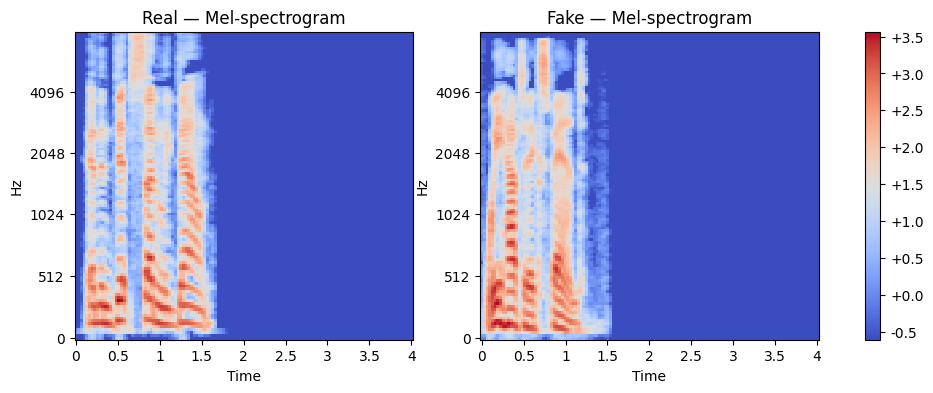

In [15]:
# Qualitative check: one real vs one fake spectrogram
real_example = train_df[train_df['label'] == 0].iloc[0]['filepath']
fake_example = train_df[train_df['label'] == 1].iloc[0]['filepath']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, path, title in zip(axes, [real_example, fake_example], ['Real', 'Fake']):
    spec = extract_melspectrogram(path)
    img = librosa.display.specshow(spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f"{title} — Mel-spectrogram")
fig.colorbar(img, ax=list(axes), format='%+.1f')
plt.savefig('sample_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def extract_features_dataset(dataframe, desc=""):
    feats, labels = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=desc):
        try:
            feats.append(extract_melspectrogram(row['filepath']))
            labels.append(row['label'])
        except Exception as e:
            print(f"Skipping {row['filepath']}: {e}")
    X = np.array(feats)[..., np.newaxis]  # (N, n_mels, time_frames, 1)
    y = np.array(labels)
    return X, y

X_train, y_train = extract_features_dataset(train_df, desc="train")
X_val, y_val = extract_features_dataset(val_df, desc="val")
X_test, y_test = extract_features_dataset(test_df, desc="test")

print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

train:   0%|          | 0/7749 [00:00<?, ?it/s]

val:   0%|          | 0/1660 [00:00<?, ?it/s]

test:   0%|          | 0/1661 [00:00<?, ?it/s]

X_train: (7749, 128, 126, 1)  X_val: (1660, 128, 126, 1)  X_test: (1661, 128, 126, 1)


## Section 3: Build the CNN

A compact 2D CNN, standard for spectrogram-as-image classification:
- 3 convolutional blocks (`Conv2D → BatchNorm → ReLU → MaxPool`), 16 / 32 / 64 filters
- **Global average pooling** instead of flattening — stays agnostic to spectrogram time-length, no flatten size to hand-compute if `DURATION` changes
- Dropout + a small dense head, ending in a 2-way softmax (`real` vs `fake`)
Kept lightweight since a few thousand clips doesn't support a much deeper network without overfitting; the tuning section below compares variants rather than hand-picking one configuration.

In [18]:
def build_cnn(input_shape, num_classes=2, dropout=0.3, num_filters=(16, 32, 64)):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for f in num_filters:
        x = layers.Conv2D(f, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

model = build_cnn(INPUT_SHAPE)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 126, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,034 (109.51 KB)

 Trainable params: 27,810 (108.63 KB)

 Non-trainable params: 224 (896.00 B)

## Section 4: Train and Tune the CNN

Training uses:
- **Class weights** — computed from the training split so an imbalanced real/fake ratio doesn't bias the model toward the majority class.
- **Early stopping** on validation loss, restoring the best-performing weights.
- **ReduceLROnPlateau** to lower the learning rate when validation loss plateaus, rather than fixing one learning rate for the whole run.
- A **checkpoint** saved to disk (`best_cnn_model.keras`) so the trained model can be reloaded later for the live demo without retraining.

In [19]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0001290655653072, 1: 0.9998709677419355}


In [20]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint('best_cnn_model.keras', monitor='val_loss', save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.6010 - loss: 0.6753 - val_accuracy: 0.4988 - val_loss: 0.7455 - learning_rate: 0.0010
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7033 - loss: 0.5872 - val_accuracy: 0.7337 - val_loss: 0.5679 - learning_rate: 0.0010
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7438 - loss: 0.5491 - val_accuracy: 0.7663 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7544 - loss: 0.5237 - val_accuracy: 0.6819 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7713 - loss: 0.5007 - val_accuracy: 0.6940 - val_loss: 0.5833 - learning_rate: 0.0010
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7837 - loss: 0.4726 - val_accuracy: 0.7012 - val_loss: 0.5670 - learning_rate: 0.0010
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8022 - loss: 0

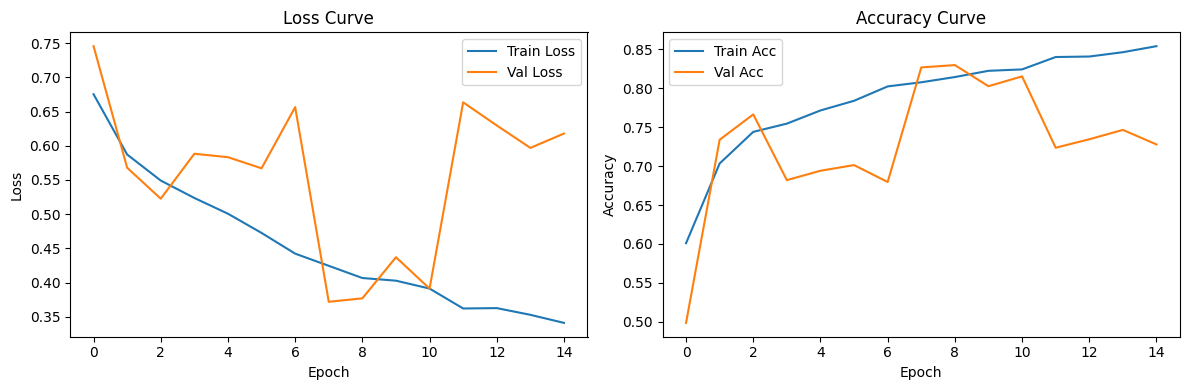

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curve')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

### Section 4b: Hyperparameter search (optional, if time/compute allows)

A small comparison of learning rate and dropout, each run for fewer epochs with early stopping. This is what "tuning" means for the report — a couple of tried configurations compared on validation accuracy, not a single number picked by hand. Extend the grids (e.g. `num_filters`, `batch_size`) if you have compute budget left; keep it small otherwise, since each config retrains the whole network.

If a configuration here beats the main run above, rerun the training cells with that `lr` / `dropout` substituted in, then redo Section 5 on that model.

In [ ]:
def run_experiment(lr, dropout, epochs=15, batch_size=32, verbose=0):
    keras.backend.clear_session()
    m = build_cnn(INPUT_SHAPE, dropout=dropout)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs,
              batch_size=batch_size, class_weight=class_weight_dict, callbacks=[es], verbose=verbose)
    return max(h.history['val_accuracy'])

search_results = []
for lr in [1e-3, 1e-4]:
    for dropout in [0.2, 0.4]:
        val_acc = run_experiment(lr, dropout)
        search_results.append({'lr': lr, 'dropout': dropout, 'best_val_acc': val_acc})
        print(f"lr={lr}  dropout={dropout}  best_val_acc={val_acc:.4f}")

search_df = pd.DataFrame(search_results).sort_values('best_val_acc', ascending=False)
search_df

lr=0.001  dropout=0.2  best_val_acc=0.7855
lr=0.001  dropout=0.4  best_val_acc=0.8012


## Section 5: Evaluate

All metrics below are computed on the **held-out test set** (never seen during training or tuning). Predictions and probabilities come from the best model — `restore_best_weights=True` already loaded it back into `model`, and the same weights are saved in `best_cnn_model.keras`.

Label convention: `1 = fake`. So *precision* = of the clips flagged fake, how many really were; *recall* = of the truly fake clips, how many were caught.

In [22]:
y_probs_all = model.predict(X_test, verbose=0)      # shape (N, 2) -> softmax over [real, fake]
y_probs = y_probs_all[:, 1]                          # P(fake)
y_pred = np.argmax(y_probs_all, axis=1)
y_true = y_test

In [23]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], zero_division=0))

Accuracy:  0.8453
Precision: 0.8118
Recall:    0.8988
F1-score:  0.8531

              precision    recall  f1-score   support

        Real       0.89      0.79      0.84       831
        Fake       0.81      0.90      0.85       830

    accuracy                           0.85      1661
   macro avg       0.85      0.85      0.84      1661
weighted avg       0.85      0.85      0.84      1661



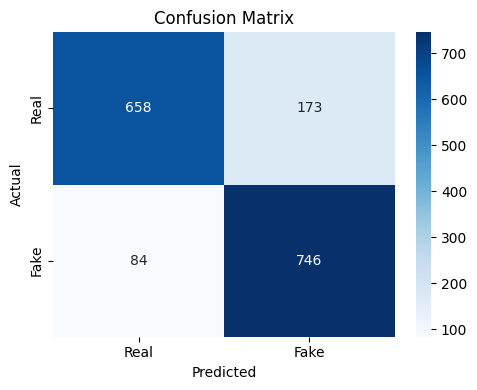

In [24]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

ROC-AUC: 0.9245
EER (nearest-point): 0.1698
EER (interpolated):  0.1697


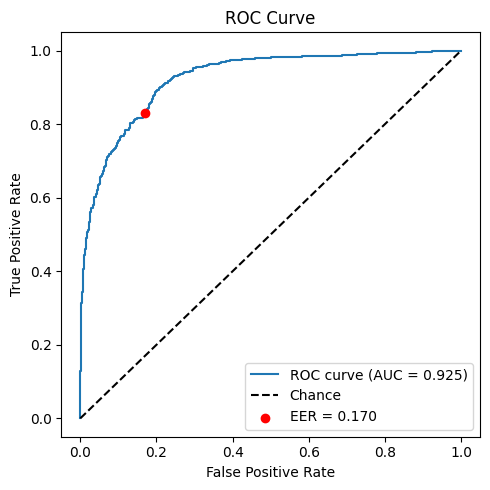

In [25]:
roc_auc = roc_auc_score(y_true, y_probs)
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
fnr = 1 - tpr

# EER = point where the false-positive rate equals the false-negative rate.
# Two ways to get it, kept together as a cross-check: a direct nearest-point estimate,
# and a more precise version found by interpolating the ROC curve and solving fpr(x) = fnr(x).
idx = np.nanargmin(np.abs(fnr - fpr))
eer_simple = (fpr[idx] + fnr[idx]) / 2

eer_interp_fn = interp1d(fpr, fnr)
eer = brentq(lambda x: eer_interp_fn(x) - x, 0., 1.)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (nearest-point): {eer_simple:.4f}")
print(f"EER (interpolated):  {eer:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.scatter([eer], [1 - eer], color='red', zorder=5, label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [26]:
import datetime

ckpt_path = os.path.join(PROJECT_PATH, "results", "best_cnn_model.keras")
if os.path.exists(ckpt_path):
    mtime = datetime.datetime.fromtimestamp(os.path.getmtime(ckpt_path))
    print(f"Found on Drive, last saved: {mtime}")
else:
    print("Not found on Drive.")

Not found on Drive.


## Section 6: Save Best Checkpoint to Drive

Colab's local runtime storage (where `ModelCheckpoint` in Section 4 saves `best_cnn_model.keras`) is wiped whenever the runtime disconnects or restarts -- it does **not** survive between sessions. Run this once after training (same session, before disconnecting) so the trained model is available later for the live demo without retraining.

In [27]:
import shutil

CHECKPOINT_NAME = 'best_cnn_model.keras'   # must match the filename in the Section 4 ModelCheckpoint
DST_DIR = f"{PROJECT_PATH}/results"
dst_path = os.path.join(DST_DIR, CHECKPOINT_NAME)

if os.path.exists(CHECKPOINT_NAME):
    os.makedirs(DST_DIR, exist_ok=True)
    shutil.copy(CHECKPOINT_NAME, dst_path)
    print(f"Saved checkpoint to Drive: {dst_path}")
else:
    print(
        f"'{CHECKPOINT_NAME}' isn't in the current runtime's local storage (cwd: {os.getcwd()}). "
        f"This means either training (Section 4) hasn't been run yet in this session, or the "
        f"runtime was reset since it last ran -- rerun Section 4 in this session, then rerun this cell."
    )

Saved checkpoint to Drive: /content/drive/MyDrive/Spoken_Project/results/best_cnn_model.keras
